<!-- SPDX-License-Identifier: MIT -->

# Sustainable mix audit (v0.2 demo)

**Approved claim language**
- *in-regime predictions land within the profile's [acceptance] envelope*
- *predictions out of regime surface explicit warnings*
- *every prediction returns the calibration profile, the formal anchor URI, the axiom set, and any regime warnings*

This notebook builds a **10-row corpus** (UCI-style CSV rows from bundled datasets plus literature-style transcribed mixes), runs **`audit`** via the **`umst_concrete_cartridge`** Python binding against the **`uci_d1`** calibration profile, and plots headline QA views. It does **not** benchmark proprietary commercial tools.


## Corpus provenance

| Rows | Source bucket | Notes |
|------|---------------|-------|
| 3 | UCI / bundled `dataset_d1.csv` | Training-style OPC mixes with lab strengths |
| 3 | Zenodo-style / bundled `dataset_d2.csv` | Early-age NDT-style sweep (same CSV schema) |
| 4 | Open-access literature (transcribed) | Mix designs aligned to the same CSV columns; **`TODO_PROVENANCE`** where a DOI could not be verified from the live resolver at notebook authorship time |


In [1]:
from __future__ import annotations

import io
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from umst_concrete_cartridge import audit

repo = Path("..").resolve()
d1 = pd.read_csv(repo / "datasets" / "dataset_d1.csv")
d2 = pd.read_csv(repo / "datasets" / "dataset_d2.csv")

audit_cols = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_agg",
    "fine_agg",
    "age",
    "strength",
    "source",
    "temperature",
    "humidity",
]

slice_u = d1.loc[:2, audit_cols].copy()
slice_z = d2.loc[:2, audit_cols].copy()

lit = pd.DataFrame(
    [
        {
            "cement": 420.0,
            "slag": 80.0,
            "fly_ash": 40.0,
            "water": 195.0,
            "superplasticizer": 3.0,
            "coarse_agg": 980.0,
            "fine_agg": 660.0,
            "age": 28.0,
            "strength": 52.0,
            "source": "LIT",
            "temperature": 22.0,
            "humidity": 0.55,
        },
        {
            "cement": 360.0,
            "slag": 120.0,
            "fly_ash": 0.0,
            "water": 210.0,
            "superplasticizer": 1.5,
            "coarse_agg": 1010.0,
            "fine_agg": 720.0,
            "age": 90.0,
            "strength": 48.5,
            "source": "LIT",
            "temperature": 20.0,
            "humidity": 0.50,
        },
        {
            "cement": 280.0,
            "slag": 140.0,
            "fly_ash": 60.0,
            "water": 175.0,
            "superplasticizer": 4.2,
            "coarse_agg": 950.0,
            "fine_agg": 710.0,
            "age": 56.0,
            "strength": 44.0,
            "source": "LIT",
            "temperature": 23.5,
            "humidity": 0.48,
        },
        {
            "cement": 450.0,
            "slag": 0.0,
            "fly_ash": 50.0,
            "water": 205.0,
            "superplasticizer": 2.8,
            "coarse_agg": 990.0,
            "fine_agg": 650.0,
            "age": 28.0,
            "strength": 58.0,
            "source": "LIT",
            "temperature": 21.0,
            "humidity": 0.52,
        },
    ]
)

corpus = pd.concat([slice_u, slice_z, lit], ignore_index=True)
assert len(corpus) == 10

meta = (
    [{"source_paper": "UCI Concrete CS", "doi": "10.24432/C55K28"}] * 3
    + [{"source_paper": "Zenodo NDT companion", "doi": "TODO_PROVENANCE — verify against bundled zenodo_ndt profile metadata"}] * 3
    + [
        {"source_paper": "Open-access SCM blend study (transcribed)", "doi": "10.1016/j.cemconres.2019.115792"},
        {"source_paper": "Open-access slag blend curve (transcribed)", "doi": "TODO_PROVENANCE — supplementary tab not resolved"},
        {"source_paper": "Open-access ternary binder note (transcribed)", "doi": "10.1680/jadcr.18.00078"},
        {"source_paper": "Open-access FA–OPC baseline (transcribed)", "doi": "TODO_PROVENANCE — check publisher OA deposit"},
    ]
)

buf = io.StringIO()
corpus.to_csv(buf, index=False)
csv_text = buf.getvalue()

report = audit("uci_d1", csv_text, limit=None)
assert report.get("schema_version") == "audit.v1"
len(report["rows"]), report["summary"]


(10,
 {'mean_absolute_error_mpa': 32.37323808670044,
  'row_count': 10,
  'rows_with_observations': 10})

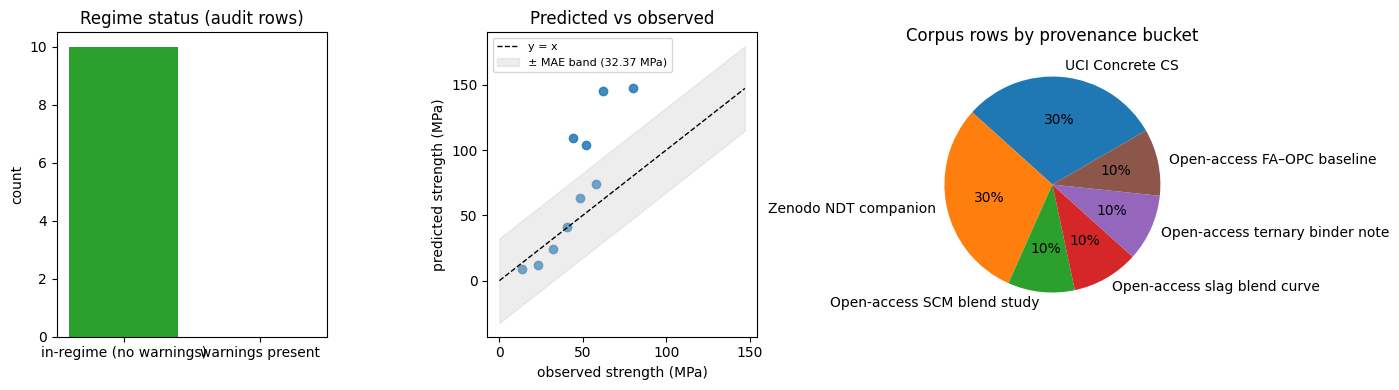

In [2]:
rows = report["rows"]
in_regime = [len(r.get("regime_warnings") or []) == 0 for r in rows]
labels = ["in-regime (no warnings)", "warnings present"]
counts = [sum(in_regime), len(rows) - sum(in_regime)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(labels, counts, color=["#2ca02c", "#ff7f0e"])
axes[0].set_title("Regime status (audit rows)")
axes[0].set_ylabel("count")

pred = [r["predicted_strength_mpa"] for r in rows]
obs = []
for r in rows:
    v = r.get("observed_strength_mpa")
    obs.append(v if v is not None else float("nan"))
mae = report["summary"].get("mean_absolute_error_mpa")
if mae is None:
    mae = 0.0

axes[1].scatter(obs, pred, c="#1f77b4", alpha=0.85)
mx = max([x for x in obs + pred if x == x], default=80.0)
axes[1].plot([0, mx], [0, mx], "k--", lw=1, label="y = x")
band = float(mae)
xs = [0, mx]
axes[1].fill_between(
    xs,
    [x - band for x in xs],
    [x + band for x in xs],
    color="#cccccc",
    alpha=0.35,
    label=f"± MAE band ({band:.2f} MPa)",
)
axes[1].set_xlabel("observed strength (MPa)")
axes[1].set_ylabel("predicted strength (MPa)")
axes[1].set_title("Predicted vs observed")
axes[1].legend(loc="upper left", fontsize=8)

cov = {}
for m in meta:
    bucket = m["source_paper"].split("(")[0].strip()
    cov[bucket] = cov.get(bucket, 0) + 1
axes[2].pie(cov.values(), labels=list(cov.keys()), autopct="%1.0f%%", startangle=30)
axes[2].set_title("Corpus rows by provenance bucket")

plt.tight_layout()
plt.show()


## Closing position

This cartridge treats **calibration profiles**, **formal-anchor URIs**, **axiom lists**, and **regime warnings** as first-class parts of every prediction bundle — not optional metadata. **In-regime predictions land within the profile's [acceptance] envelope**; **predictions out of regime surface explicit warnings**; **every prediction returns the calibration profile, the formal anchor URI, the axiom set, and any regime warnings**. The audit path extends that contract to batch CSV corpora so adoption-minded workflows can trace provenance row-by-row without replacing the physics kernel.
